In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the updated dataset
df = pd.read_csv("updated_counts_severity_dataset.csv")

# Ensure the target column has no missing values
df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
df["lyrics"].fillna("", inplace=True)

# Define feature sets
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]

# Combine features for modeling
all_features = category_severity_features + numerical_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable


In [3]:
# Convert lyrics to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
X_text = tfidf.fit_transform(df["lyrics"])

# Normalize numerical features
imputer = SimpleImputer(strategy="mean")
scaler = MinMaxScaler()

X_numerical_imputed = imputer.fit_transform(X_numerical)
X_numerical_scaled = scaler.fit_transform(X_numerical_imputed)

# Combine text and numerical features
X_combined = hstack([X_text, X_numerical_scaled])


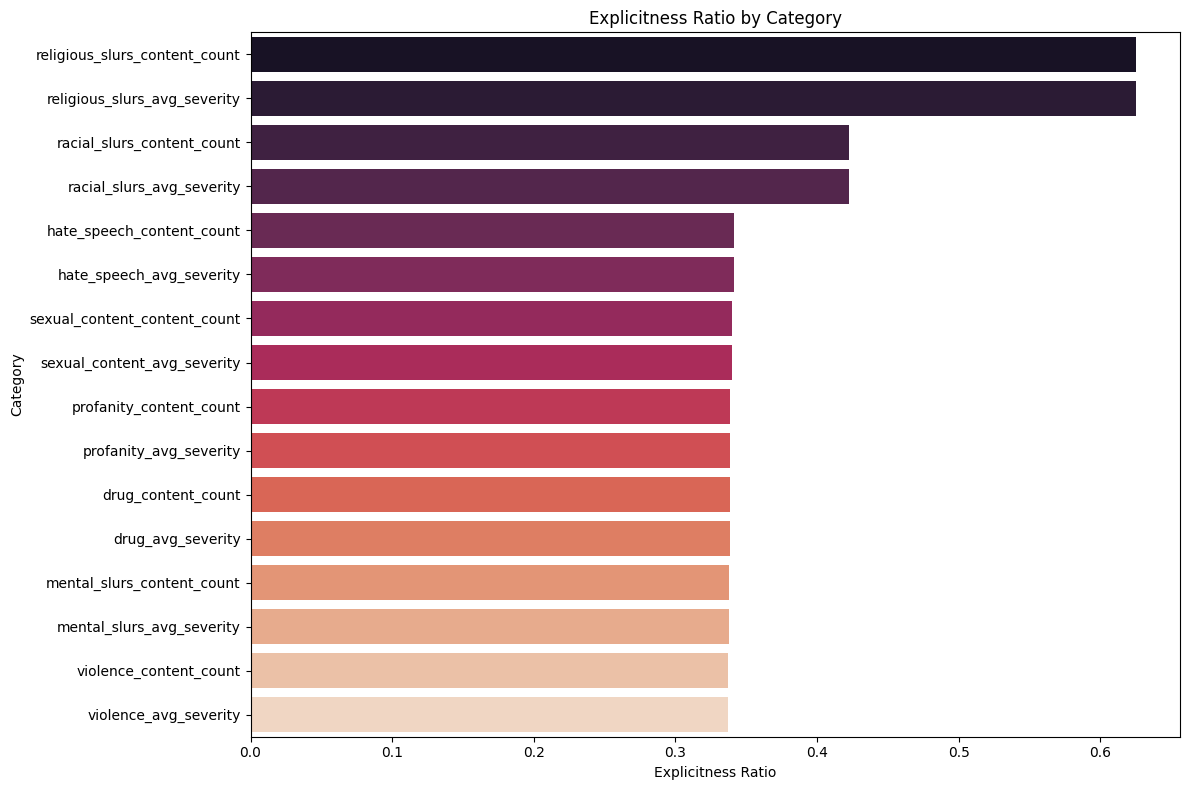

In [4]:
# Analyze explicitness ratios for count and severity features
category_ratios = {}
for category in category_count_features + category_severity_features:
    ratio = df[df[category] > 0]["explicit"].mean()
    category_ratios[category] = ratio

# Convert to DataFrame for visualization
category_ratios_df = pd.DataFrame({
    "Category": category_ratios.keys(),
    "Explicit Ratio": category_ratios.values()
}).sort_values(by="Explicit Ratio", ascending=False)

# Plot explicitness ratios
plt.figure(figsize=(12, 8))
sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")
plt.title("Explicitness Ratio by Category")
plt.xlabel("Explicitness Ratio")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


Naive Bayes Accuracy: 0.7112264763140818
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.98      0.82      1027
         1.0       0.84      0.17      0.28       514

    accuracy                           0.71      1541
   macro avg       0.77      0.57      0.55      1541
weighted avg       0.75      0.71      0.64      1541



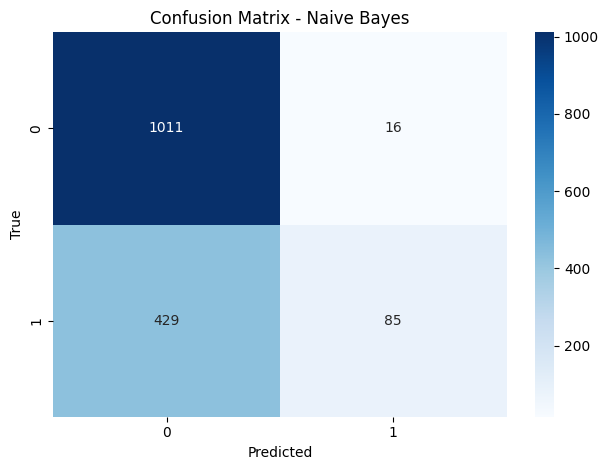

Naive Bayes class distribution: 0.0    1440
1.0     101
Name: count, dtype: int64


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Evaluate Naive Bayes
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

# Plot confusion matrix
nb_cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("Naive Bayes class distribution:", pd.Series(y_pred_nb).value_counts())


KNN Accuracy: 0.81829980532122
Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1027
         1.0       0.76      0.67      0.71       514

    accuracy                           0.82      1541
   macro avg       0.80      0.78      0.79      1541
weighted avg       0.82      0.82      0.82      1541



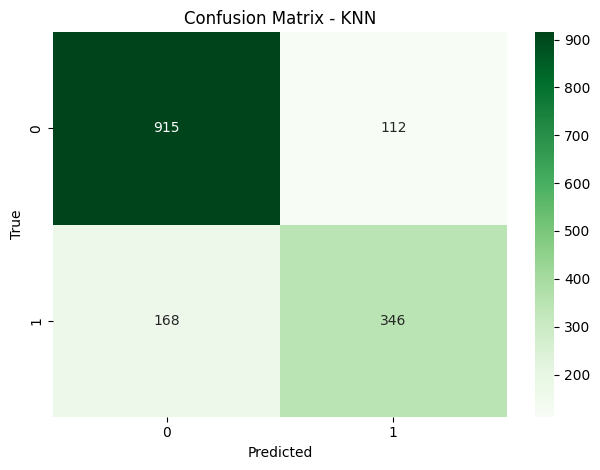

KNN class distribution: 0.0    1083
1.0     458
Name: count, dtype: int64


In [6]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Evaluate KNN
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# Plot confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("KNN class distribution:", pd.Series(y_pred_knn).value_counts())


Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.6547 - loss: 0.6362

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


193/193 ━━━━━━━━━━━━━━━━━━━━ 37s 184ms/step - accuracy: 0.6548 - loss: 0.6361 - val_accuracy: 0.7073 - val_loss: 0.5366
Epoch 2/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 35s 182ms/step - accuracy: 0.7364 - loss: 0.5282 - val_accuracy: 0.7781 - val_loss: 0.4589
Epoch 3/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 36s 186ms/step - accuracy: 0.7836 - loss: 0.4571 - val_accuracy: 0.8254 - val_loss: 0.4127
Epoch 4/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 35s 180ms/step - accuracy: 0.8252 - loss: 0.4015 - val_accuracy: 0.8196 - val_loss: 0.4012
Epoch 5/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 36s 187ms/step - accuracy: 0.8297 - loss: 0.3814 - val_accuracy: 0.8293 - val_loss: 0.3904
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8331 - loss: 0.3981
LSTM Accuracy: 0.8293


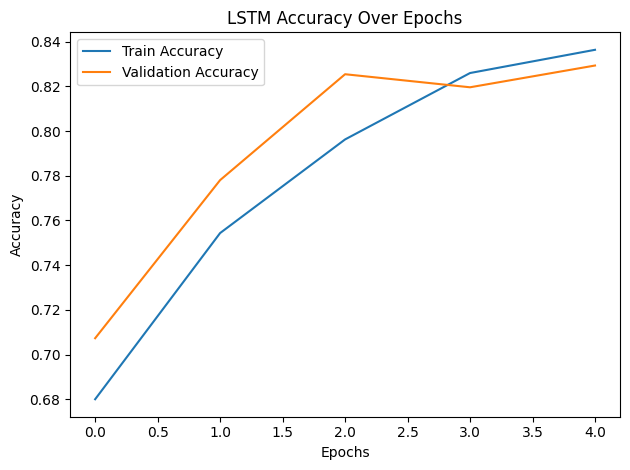

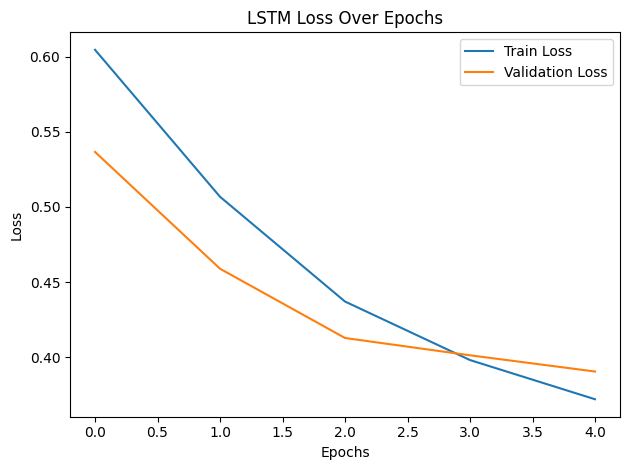

 1/49 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


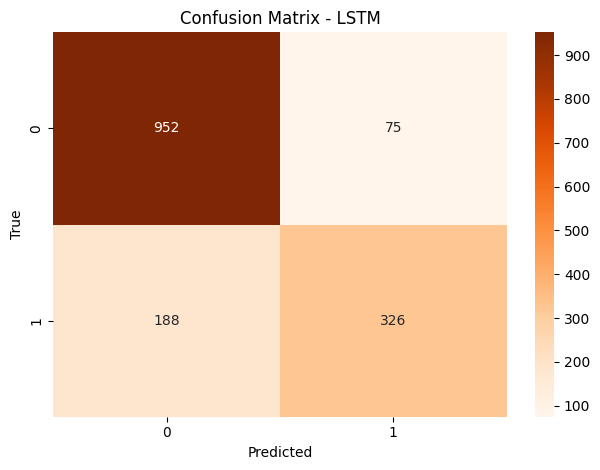

LSTM class distribution: 0    1140
1     401
Name: count, dtype: int64


In [7]:
# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["lyrics"])
X_text_seq = tokenizer.texts_to_sequences(df["lyrics"])
X_text_pad = pad_sequences(X_text_seq, maxlen=300)

# Train-test split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text_pad, X_numerical_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define LSTM model
input_text = Input(shape=(300,))
input_num = Input(shape=(X_train_num.shape[1],))

text_embedding = Embedding(input_dim=5000, output_dim=64, input_length=300)(input_text)
text_lstm = LSTM(128)(text_embedding)

combined = Concatenate()([text_lstm, input_num])
dense = Dense(64, activation="relu")(combined)
dropout = Dropout(0.5)(dense)
output = Dense(1, activation="sigmoid")(dropout)

model = Model(inputs=[input_text, input_num], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train LSTM
history = model.fit(
    [X_train_text, X_train_num], y_train, epochs=5, batch_size=32, 
    validation_data=([X_test_text, X_test_num], y_test)
)

# Evaluate LSTM
loss, accuracy = model.evaluate([X_test_text, X_test_num], y_test)
print(f"LSTM Accuracy: {accuracy:.4f}")

# Plot training metrics
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# LSTM confusion matrix
lstm_pred = (model.predict([X_test_text, X_test_num]) > 0.5).astype(int)
lstm_cm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("LSTM class distribution:", pd.Series(lstm_pred.flatten()).value_counts())
